# Diabetes - Exploratory Data Analysis

## Pima Indians Diabetes (n=768)

All patients are female, 21+ years old, of Pima Indian heritage. Several
columns encode missing measurements as `0` (not biologically plausible for
glucose, blood pressure, skin thickness, insulin, or BMI); this notebook
first shows the *raw* zeros, and interprets them as missing, exactly as
`src/preprocessing.py` does before imputation.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_disease
from src.preprocessing import DiseasePreprocessor
from src import eda

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
disease = get_disease("diabetes")
pre = DiseasePreprocessor(disease)
raw_df = pre.load_raw()
df = pre.clean_raw(raw_df)
print(f"Shape after cleaning: {df.shape}")
df.head()

2026-07-30 15:47:54,773 [INFO] [diabetes] loaded raw data: 768 rows x 9 cols


2026-07-30 15:47:54,774 [INFO] [diabetes] treating 5 zero-values in 'glucose' as missing


2026-07-30 15:47:54,775 [INFO] [diabetes] treating 35 zero-values in 'blood_pressure' as missing


2026-07-30 15:47:54,775 [INFO] [diabetes] treating 227 zero-values in 'skin_thickness' as missing


2026-07-30 15:47:54,776 [INFO] [diabetes] treating 374 zero-values in 'insulin' as missing


2026-07-30 15:47:54,777 [INFO] [diabetes] treating 11 zero-values in 'bmi' as missing


Shape after cleaning: (768, 9)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,target
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 1. Summary Statistics

In [3]:
eda.summary_statistics(df)

,count,mean,std,min,25%,50%,75%,max,missing,dtype
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,0,int64
glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00,5,float64
blood_pressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00,35,float64
skin_thickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00,227,float64
insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00,374,float64
bmi,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10,11,float64
diabetes_pedigree_function,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,0,float64
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,0,int64
target,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,0,int64


## 2. Missing Value Analysis

2026-07-30 15:47:54,874 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_missing_values.png


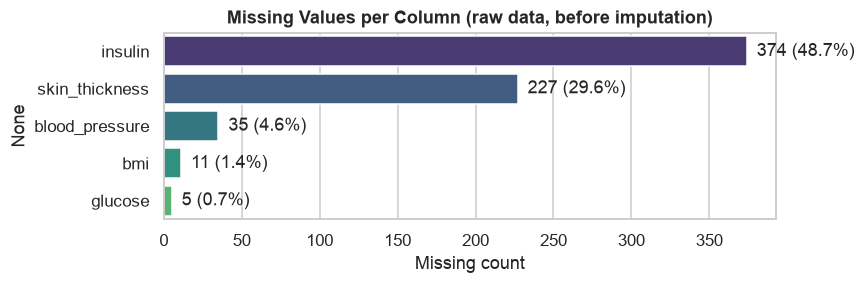

In [4]:
fig = eda.plot_missing_values(df, "diabetes")
plt.show()

**Interpretation:** Once zeros are treated as missing, `insulin` is missing
for 374/768 patients (48.7%) and `skin_thickness` for 227/768 (29.6%) - both
require a more invasive/less routine measurement than glucose or blood
pressure, which explains the gap. `blood_pressure` (35), `bmi` (11), and
`glucose` (5) are missing far less often. Given `insulin`'s near-50% missingness,
median imputation is a pragmatic choice for this project, but a production
system would want to flag `insulin`-imputed predictions as lower-confidence.


## 3. Disease Prevalence

2026-07-30 15:47:54,942 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_prevalence.png


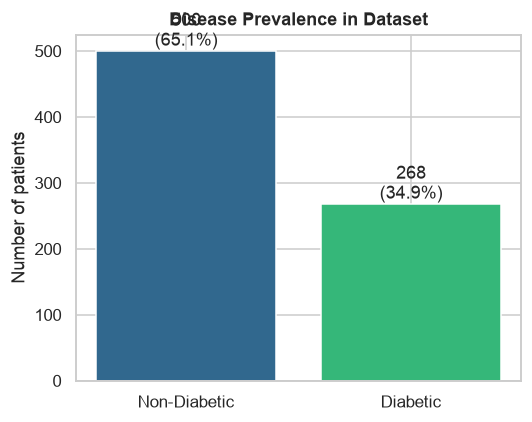

In [5]:
labels = {0: 'Non-Diabetic', 1: 'Diabetic'}
fig = eda.plot_target_prevalence(df, "target", labels, "diabetes")
plt.show()

**Interpretation:** 34.9% of patients are diabetic - a moderate class
imbalance (roughly 1:2). This is mild enough that no resampling is applied,
but it's still a reason to look at ROC-AUC and recall rather than accuracy
alone (a model predicting "non-diabetic" for everyone would already score
65% accuracy while being clinically useless).


## 4. Feature Distributions

2026-07-30 15:47:55,265 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_distributions.png


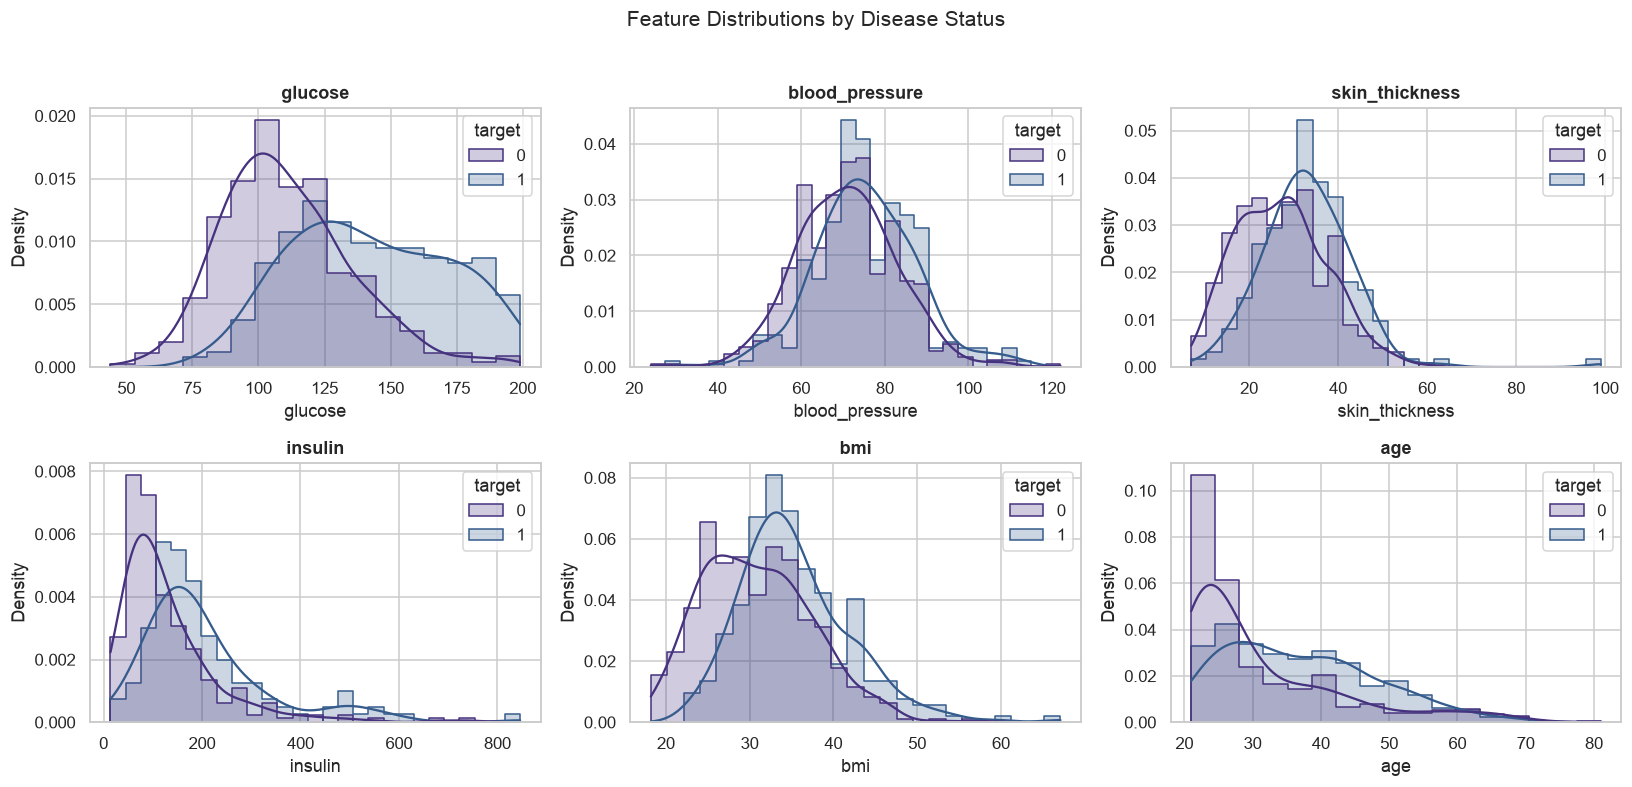

In [6]:
numeric_cols = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'age']
fig = eda.plot_numeric_distributions(df, numeric_cols, "target", "diabetes")
plt.show()

**Interpretation:** `glucose` shows the strongest visual separation between
classes - diabetic patients are shifted noticeably right, consistent with
it being part of the diagnostic criteria itself (2-hour OGTT >= 200 mg/dl).
`insulin` and `skin_thickness` are heavily right-skewed with a spike at the
(now-imputed) median, a visible artifact of the ~30-49% missingness in those
columns.


## 5. Boxplots (Outlier Visualization)

2026-07-30 15:47:55,431 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,433 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,443 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,446 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,456 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-30 15:47:55,480 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,482 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,491 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,493 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:55,630 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_boxplots.png


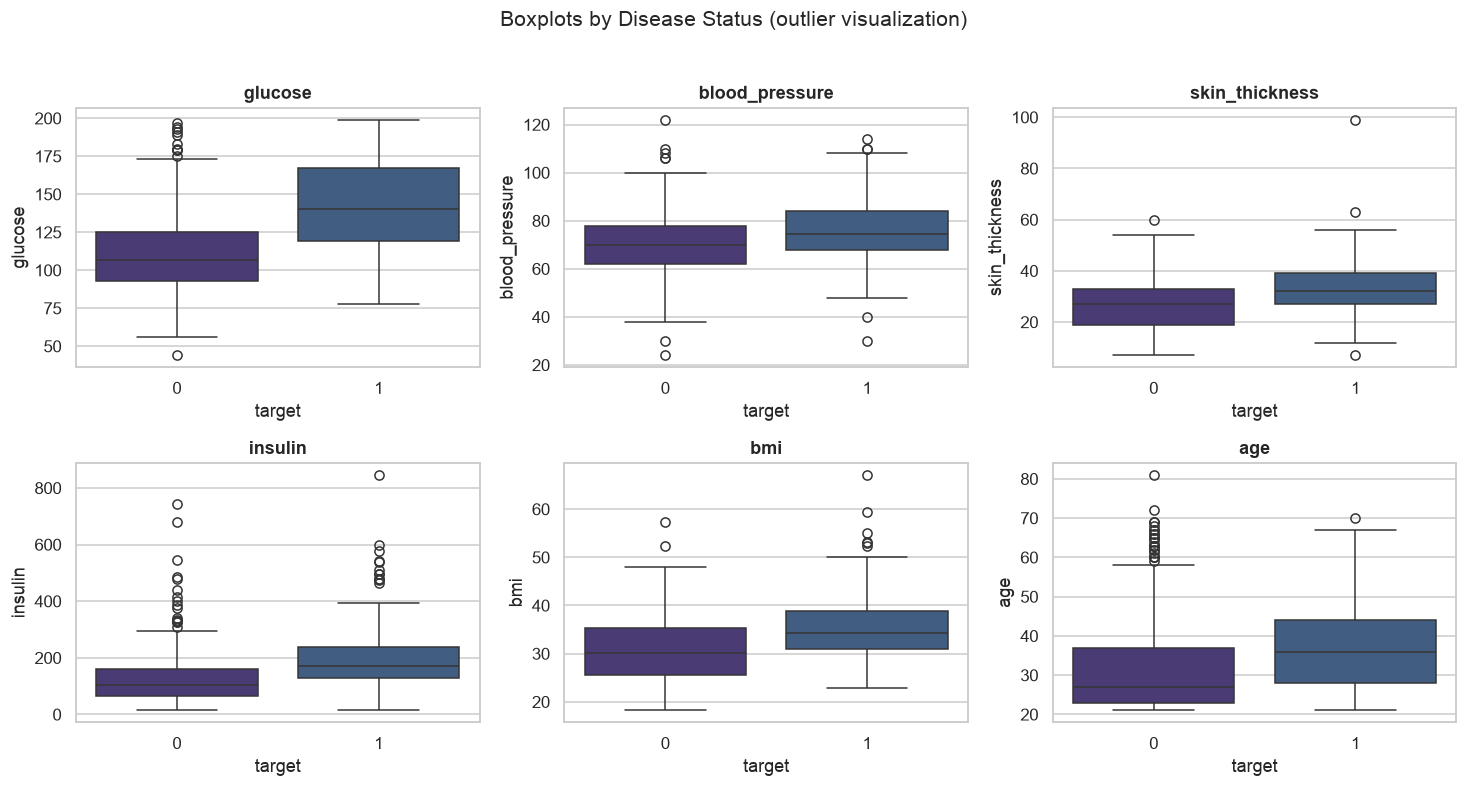

In [7]:
fig = eda.plot_boxplots(df, numeric_cols, "target", "diabetes")
plt.show()

**Interpretation:** `glucose`, `bmi`, and `insulin` all show a clear upward
median shift in the diabetic group. `skin_thickness` and `blood_pressure`
show much more overlapping boxes between groups - visually consistent with
their weaker correlation with the target reported below.


## 6. Correlation Matrix

2026-07-30 15:47:55,841 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_correlation_heatmap.png


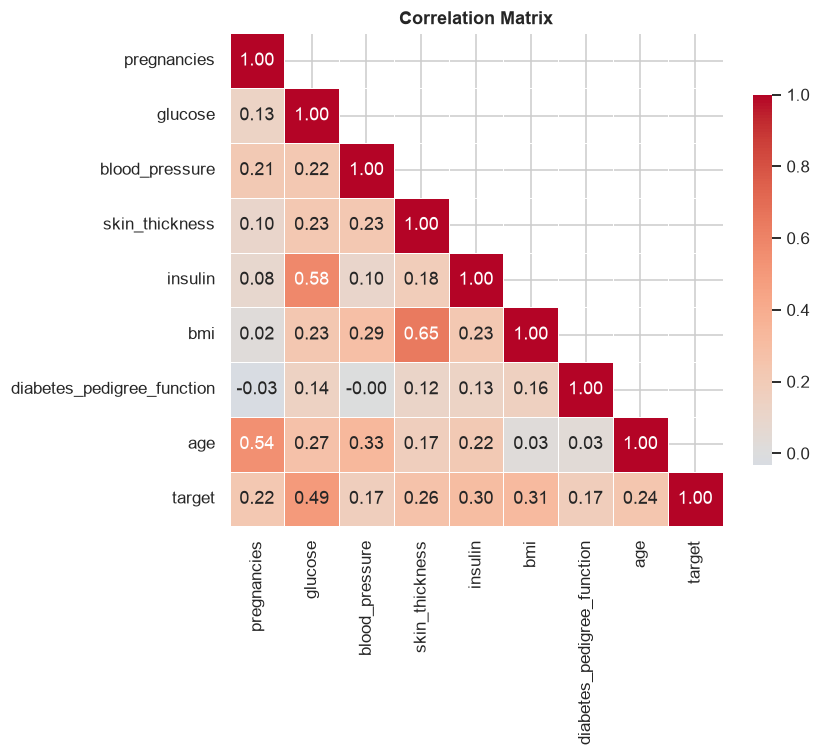

In [8]:
fig = eda.plot_correlation_heatmap(df, "diabetes")
plt.show()

In [9]:
eda.target_correlation_ranked(df, "target")

glucose                       0.494650
bmi                           0.313680
insulin                       0.303454
skin_thickness                0.259491
age                           0.238356
pregnancies                   0.221898
diabetes_pedigree_function    0.173844
blood_pressure                0.170589
Name: target, dtype: float64

**Interpretation:** Ranked by |correlation| with `target`: `glucose` (0.49),
`bmi` (0.31), `insulin` (0.30), `skin_thickness` (0.26), `age` (0.24),
`pregnancies` (0.22). `glucose` alone carries roughly as much linear signal
as the next three features combined, which matches its role as the direct
diagnostic threshold variable. `skin_thickness` and `insulin` are correlated
with each other (both reflect adiposity/insulin resistance) more than either
is with the target - a case of correlated *predictors* rather than target
leakage.


## 7. Pairplot of Top Correlated Features

2026-07-30 15:47:56,334 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/diabetes_pairplot.png


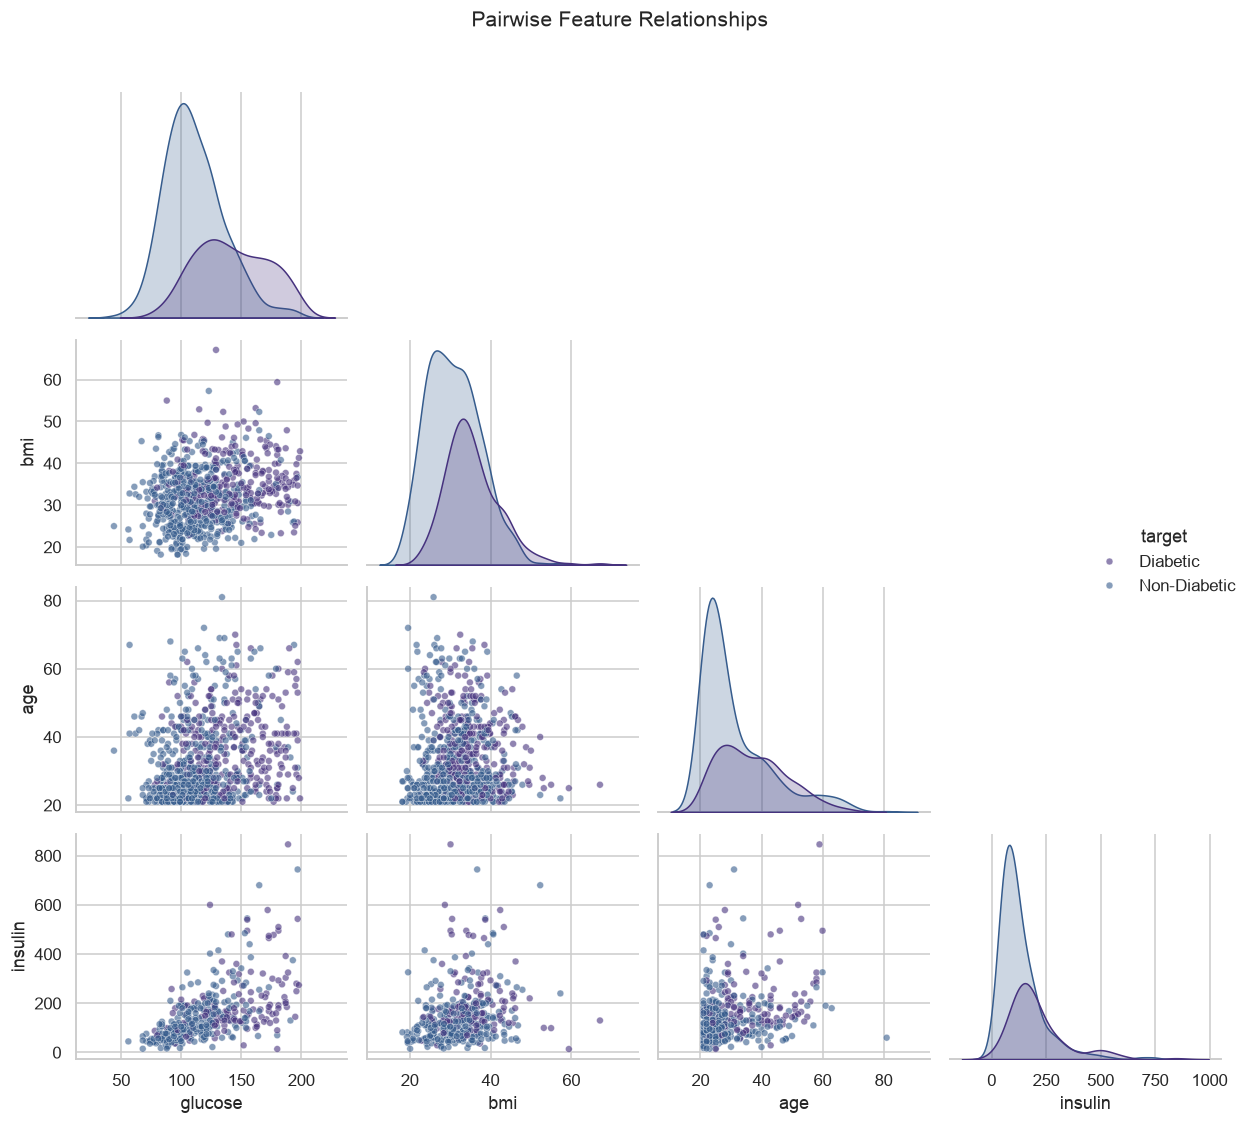

In [10]:
pair_cols = ['glucose', 'bmi', 'age', 'insulin']
fig = eda.plot_pairplot(df, pair_cols, "target", "diabetes", labels)
plt.show()

**Interpretation:** `glucose` vs `bmi` shows the diabetic class concentrated
in the upper-right region (high glucose *and* high BMI), reinforcing the
`glucose_bmi_interaction` engineered feature. `age` shows only a mild rightward
shift for the diabetic class - onset in this cohort is not tightly
age-concentrated, unlike some other diabetes cohorts in the literature.


## 8. Summary of Findings

This EDA directly informs the choices made in `src/preprocessing.py` (imputation strategy, outlier clipping) and `src/feature_engineering.py` (which engineered features to add) for this disease. See `src/train.py` for how the cleaned, engineered features feed into the TabPFN model.